In [2]:
import h5py
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score

class STEADDataset(Dataset):
    """

    This class teaches PyTorch how to retrieve ONE seismic sample
    Each call returns:
        - X = seismic waveform
        - y = label
    
    """

    def __init__(
        self,
        hdf5_path,
        csv_path,
        task="detection",
        window_size=300,
        p_before=50,
        normalize=True,
        max_samples=None
    ):
        self._h5_file = None
        self.hdf5_path = hdf5_path
        self.task = task
        self.window_size = window_size
        self.p_before = p_before
        self.normalize = normalize
        self.max_samples = max_samples
        df = pd.read_csv(csv_path)
        if task in ["magnitude", "forecasting"]:
            df = df[
                df["trace_category"] == "earthquake_local"
            ]
            df = df[
                df["p_arrival_sample"].notna()
            ]
            df = df[
                df["p_arrival_sample"] > p_before
            ]
            df = df[
                df["p_arrival_sample"] + window_size < 6000
            ]
        if max_samples is not None:

            number_to_keep = min(
                max_samples,
                len(df)
            )
            df = df.sample(
                number_to_keep,
                random_state=42
            )
        self.metadata = df.reset_index(drop=True)
        print(
            f"Dataset contains {len(self.metadata)} samples."
        )

    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        trace_name = row["trace_name"]
        if self._h5_file is None:
            self._h5_file = h5py.File(self.hdf5_path, "r")
        waveform = self._h5_file["data"][trace_name][:]
        waveform = waveform.astype(np.float32)
        if self.task == 'detection':
            return self._detection_sample(waveform, row)
        elif self.task == 'magnitude':
            return self._magnitude_sample(waveform, row)
        elif self.task == 'forecasting':
            return self._forecasting_sample(waveform, row)
    
    def _normalize_waveform(self, waveform):

        mean = waveform.mean(axis=0, keepdims=True)
        std = waveform.std(axis=0, keepdims=True) + 1e-8

        return (waveform - mean) / std

    def _detection_sample(self, waveform, row):
        is_earthquake = int(
            row["trace_category"] == "earthquake_local"
        )
        if waveform.shape[0] == 3 and waveform.shape[1] != 3:
            waveform = waveform.T
        if is_earthquake and pd.notna(row["p_arrival_sample"]):
            p_idx = int(row["p_arrival_sample"])
            start = max(
                0,
                p_idx - self.p_before
            )
            end = start + self.window_size
            if end > waveform.shape[0]:
                end = waveform.shape[0]
                start = end - self.window_size
        else:
            start = np.random.randint(
                0,
                waveform.shape[0] - self.window_size
            )
            end = start + self.window_size
        window = waveform[start:end, :]
        if self.normalize:
            window = self._normalize_waveform(window)
        return (
            torch.tensor(window, dtype=torch.float32),
            torch.tensor(is_earthquake, dtype=torch.long)
        )

    def _magnitude_sample(self, waveform, row):

        # Make waveform consistent:
        # (channels, time) -> (time, channels)
        if waveform.shape[0] == 3 and waveform.shape[1] != 3:
            waveform = waveform.T


        p_idx = int(row["p_arrival_sample"])

        start = p_idx
        end = start + self.window_size


        # Now select time dimension correctly
        window = waveform[start:end, :]   # (window_size, 3)


        if self.normalize:
            window = self._normalize_waveform(window)


        magnitude = float(row["source_magnitude"])
        distance = float(row["source_distance_km"])


        magnitude = (magnitude - 1.0) / 5.0
        distance = np.log1p(distance) / 10.0


        return (
            torch.tensor(window, dtype=torch.float32),
            torch.tensor(
                [magnitude, distance],
                dtype=torch.float32
            )
        )
    
    def _forecasting_sample(self, waveform, row):
        if waveform.shape[0] == 3 and waveform.shape[1] != 3:
            waveform = waveform.T

        p_idx = int(row["p_arrival_sample"])
        encoder_length = self.window_size // 3 
        decoder_length = self.window_size        
        total_length = encoder_length + decoder_length
        encoder_length = 300
        decoder_length = 900
        total_length = encoder_length + decoder_length

        start = max(0, p_idx - self.p_before)

        
        start = min(start, waveform.shape[0] - total_length)
        end = start + total_length

        segment = waveform[start:end, :]  

        if self.normalize:
            segment = self._normalize_waveform(segment)

        encoder_input = segment[:encoder_length, :]      
        decoder_target = segment[encoder_length:, :]   

        return (
            torch.tensor(encoder_input, dtype=torch.float32),
            torch.tensor(decoder_target, dtype=torch.float32),
        )

def create_loaders(
    hdf5_path,
    csv_path,
    task,
    batch_size=64,
    max_samples=50000,
    **dataset_kwargs
):
    dataset = STEADDataset(
        hdf5_path,
        csv_path,
        task=task,
        max_samples=max_samples,
        **dataset_kwargs
    )

    n = len(dataset)
    train_n = int(0.7 * n)
    val_n = int(0.15 * n)
    test_n = n - train_n - val_n

    train_set, val_set, test_set = torch.utils.data.random_split(
        dataset,
        [train_n, val_n, test_n],
        generator=torch.Generator().manual_seed(42)
    )

    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,       # Required for notebook/macOS reliability
            pin_memory=False,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size * 2,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        ),
        DataLoader(
            test_set,
            batch_size=batch_size * 2,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        ),
    )

        

In [3]:
class GRUDetector(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_size, 32, kernel_size=7, padding=3), # 1D CONV: Lout = Lin + 2p - K + 1 so Lout=300+2x-7 + 1 and x=3
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        
        self.gru = nn.GRU(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

        self._init_weights()
    
    def _init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
    
    def forward(self, x):
        x_conv = x.permute(0, 2, 1)  # (batch, 3, seq_len)
        features = self.feature_extractor(x_conv) # (batch, 64, seq_len)
        features = features.permute(0, 2, 1) # GRU wants (batch, seq_len, features)
        gru_out, _ = self.gru(features) # (batch, seq_len, hidden*2)
        pooled, _ = gru_out.max(dim=1) # (batch, hidden*2) and for each of the 256 features, take its maximum value across all 300 timesteps.
        logits = self.classifier(pooled) # (batch, 2) final two values are [noise_score, earthquake_score]
        return logits
    
    def predict_proba(self, x):
        return F.softmax(self.forward(x), dim=1) # dim=1 = across the 2 classes

def train_detector(model, train_loader, val_loader, n_epochs=30, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=1e-3, 
        steps_per_epoch = len(train_loader),
        epochs=n_epochs
    )
    criterion = nn.CrossEntropyLoss()
    best_val_f1 = 0
    history = {'train_loss': [], 'val_f1': [], 'val_auc': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for waveforms, labels in train_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(waveforms)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        model.eval()
        all_preds, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for waveforms, labels in val_loader:
                waveforms = waveforms.to(device)
                logits = model(waveforms)
                probs = F.softmax(logits, dim=-1)[:, 1]
                preds = logits.argmax(dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.numpy())
        val_f1 = f1_score(all_labels, all_preds)
        val_auc = roc_auc_score(all_labels, all_probs)
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'gru_detector_best.pth')
        print(f"EPOCH {epoch+1}/{n_epochs} | "
                f"LOSS {history['train_loss'][-1]:.4f} | "
                f"F1: {val_f1: .4f} | AUC: {val_auc: .4f}")
    return history


In [4]:
class LSTMEstimator(nn.Module):
    def __init__(self, input_size=3, hidden_size=256, n_layers=3, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 32, kernel_size=11, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.magnitude_head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        self.distance_head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        self._init_weights()
    
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                n = param.size(0)
                param.data[n//4:n//2].fill_(1.0)

    def forward(self, x):
        """
        x: (batch, seq_len, 3)
        returns: magnitude pred (batch, ), distance pred (batch, ), attention_weights (batch, seq_len)
        """

        # 1) Permute x
        # before conv: x.shape = (batch, 500, 3) because LSTM expects (batch, time, features) but Conv1d
        # expects (batch, features, time)  so we permute and run convolutional layer
        x_conv = x.permute(0, 2, 1)
        features = self.conv(x_conv)

        # 2) Permute features back to (batch, time, features)
        features = features.permute(0, 2, 1)

        # 3) Run LSTM 
        # Input: (64, 500, 128) and LSTM has hidden size = 256 so output is (64, 500, 256)
        lstm_out, _ = self.lstm(features)

        # 4) Attention
        # Input: (64, 500, 256), for every timestep produces a score
        attn_scores = self.attention(lstm_out)

        # 5) Softmax Attention weights
        # dimension we want to normalize across is time
        attn_weights = F.softmax(attn_scores, dim=1)

        # 6) Weighted Sum
        # Each timestep's 256 hidden values gets multiplied by its importance weight
        # each t0 becomes [0.1, 0.2, 0.3] and t1 becomes [3.6, 4.5, 5.4] and then you add timewirse 
        # so it becomes [3.7, 4.7, 5.7]
        # output shape: (64, 256)
        context = (attn_weights * lstm_out).sum(dim=1)

        # 7) Magnitude
        # Output: (64, )
        magnitude = self.magnitude_head(context).squeeze(-1)

        # 8) Distance
        distance = self.distance_head(context).squeeze(-1)

        return magnitude, distance, attn_weights.squeeze(-1)

    def predict(self, x):
        """
        forward(x) gives predictions in the normalized form the model was trained on.
        predict(x) converts them back to normal real-world values:  
        normalized magnitude -> real magnitude
        normalized distance  -> real distance in km
        """

        mag_norm, dist_norm, attn = self.forward(x)
        magnitude = mag_norm * 5.0 + 1.0
        distance = torch.expm1(dist_norm * 10.0)
        return magnitude, distance, attn

def train_estimator(model, train_loader, val_loader, n_epochs=30, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    best_val_mae = float('inf')
    history = {'train_loss': [], 'val_mag_mae': [], 'val_dist_mae': []}
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for waveforms, targets in train_loader:
            waveforms = waveforms.to(device)
            targets = targets.to(device)
            mag_target = targets[:, 0]  
            dist_target = targets[:, 1]
            optimizer.zero_grad()
            mag_pred, dist_pred, _ = model(waveforms)
            mag_loss = F.mse_loss(mag_pred, mag_target)
            dist_loss = F.mse_loss(dist_pred, dist_target)
            loss = mag_loss + 0.5 * dist_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        model.eval()
        mag_errors, dist_errors = [], []
        with torch.no_grad():
            for waveforms, targets in val_loader:
                waveforms = waveforms.to(device)
                targets = targets.to(device)
                mag_pred, dist_pred, _ = model(waveforms)
                mag_mae = (mag_pred - targets[:, 0]).abs().mean().item() * 1.5
                dist_mae = (dist_pred - targets[:, 1]).abs().mean().item()
                mag_errors.append(mag_mae)
                dist_errors.append(dist_mae)
        val_mag_mae = np.mean(mag_errors)
        val_dist_mae = np.mean(dist_errors)
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_mag_mae'].append(val_mag_mae)
        history['val_dist_mae'].append(val_dist_mae)
        if val_mag_mae < best_val_mae:
            best_val_mae = val_mag_mae
            torch.save(model.state_dict(), 'lstm_estimator_best.pth')
        print(f"EPOCH {epoch+1}/{n_epochs} | "
                f"LOSS: {history['train_loss'][-1]:.4f} | "
                f"MAG MAE: {val_mag_mae:.4f} | "
                f"DIST MAE: {val_dist_mae:.1f} km")
    return history

In [5]:
class WaveformEncoder(nn.Module):
    def __init__(self, input_size=3, hidden_size=256, n_layers=2, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )

    def forward(self, x):
        """
        x: (batch, encoder_seq_len, 3)
        returns:
          encoder_outputs: (batch, encoder_seq_len, hidden) — all hidden states
          h_n: (n_layers, batch, hidden) — final hidden state
          c_n: (n_layers, batch, hidden) — final cell state
        """
        x_conv = x.permute(0, 2, 1)
        features = self.conv(x_conv).permute(0, 2, 1)
        encoder_outputs, (h_n, c_n) = self.lstm(features)
        return encoder_outputs, h_n, c_n

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W_s = nn.Linear(hidden_size, hidden_size)
        self.W_h = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: (batch, hidden) - current decoder step
        encoder_outputs: (batch, encoder_seq_len, hidden) - all encoder states

        returns:
            - context: (batch, hidden) - attention weighted encoder output
            - weights: (batch, encoder_seq_len) - attention distribution
        """

        s = self.W_s(decoder_hidden).unsqueeze(1)
        h = self.W_h(encoder_outputs)
        scores = self.v(torch.tanh(s+h)).squeeze(-1)
        weights = F.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * encoder_outputs).sum(dim=1)
        return context, weights

class WaveformDecoder(nn.Module):
    def __init__(self, output_size=3, hidden_size=256, n_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention = BahdanauAttention(hidden_size)
        self.lstm = nn.LSTM(
            input_size=output_size + hidden_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first = True,
            dropout=dropout
        )

        self.output_proj = nn.Linear(hidden_size+hidden_size, output_size)


    def forward_step(self, x_prev, h, c, encoder_outputs):
        context, attn_weights = self.attention(h[-1], encoder_outputs)
        lstm_input = torch.cat([x_prev, context], dim=-1).unsqueeze(1)
        output, (h, c) = self.lstm(lstm_input, (h, c))
        combined = torch.cat([output.squeeze(1), context], dim=-1)
        prediction = self.output_proj(combined)
        return prediction, h, c, attn_weights


class SeismicSeq2Seq(nn.Module):
    def __init__(self, hidden_size=256, n_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = WaveformEncoder(3, hidden_size, n_layers, dropout)
        self.decoder = WaveformDecoder(3, hidden_size, n_layers, dropout)
    
    def forward(self, encoder_input, decoder_target, teacher_force):
        batch_size = encoder_input.shape[0]
        dec_len = decoder_target.shape[1]
        encoder_outputs, h, c = self.encoder(encoder_input)
        predictions = []
        attention_weights = []
        x_prev = encoder_input[:, -1, :]
        for t in range(dec_len):
            pred, h, c, attn = self.decoder.forward_step(
                x_prev, h, c, encoder_outputs
            )

            predictions.append(pred)
            attention_weights.append(attn)
            use_teacher = torch.rand(1).item() < teacher_force
            x_prev = decoder_target[:, t, :] if use_teacher else pred.detach()
        
        predictions = torch.stack(predictions, dim=1)
        attention_weights = torch.stack(attention_weights, dim=1)
        return predictions, attention_weights

    def predict(self, encoder_input):
        self.eval()
        with torch.no_grad():
            encoder_outputs, h, c = self.encoder(encoder_input)
            predictions = []
            attention_weights = []
            x_prev = encoder_input[:, -1, :]
            dec_len = encoder_input.shape[1]*3
            for t in range(dec_len):
                pred, h, c, attn = self.decoder.forward_step(
                    x_prev, h, c, encoder_outputs
                )
                predictions.append(pred)
                attention_weights.append(attn)
                x_prev = pred
        return (
            torch.stack(predictions, dim=1),
            torch.stack(attention_weights, dim=1)
        )
    
def train_seq2seq(model, train_loader, val_loader, n_epochs=30, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs
    )
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        teacher_force = max(0.1, 0.9 - epoch * 0.025)
        for enc_input, dec_target in train_loader:
            enc_input = enc_input.to(device)
            dec_target = dec_target.to(device)
            optimizer.zero_grad()
            predictions, _ = model(enc_input, dec_target, teacher_force)
            loss = F.mse_loss(predictions, dec_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for enc_input, dec_target in val_loader:
                enc_input = enc_input.to(device)
                dec_target = dec_target.to(device)
                predictions, _ = model(enc_input, dec_target, teacher_force=0.0)
                val_loss += F.mse_loss(predictions, dec_target).item()
        val_loss /= len(val_loader)
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'seq2seq_best.pth')
        
        print(f"Epoch {epoch+1}/{n_epochs} | TF: {teacher_force:.2f} | "
              f"Train: {history['train_loss'][-1]:.6f} | "
              f"Val: {val_loss:.6f}")

    return history





In [6]:
# visualize.py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch


def plot_detection_roc(model, test_loader, device):
    """ROC curve and precision-recall for the GRU detector."""
    from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                                  average_precision_score)
    
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for waveforms, labels in test_loader:
            probs = model.predict_proba(waveforms.to(device))[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    prec, rec, _ = precision_recall_curve(all_labels, all_probs)
    ap = average_precision_score(all_labels, all_probs)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC AUC = {roc_auc:.3f}')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('GRU P-Wave Detector: ROC Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2.plot(rec, prec, color='coral', linewidth=2,
             label=f'Average Precision = {ap:.3f}')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('GRU P-Wave Detector: Precision-Recall Curve')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/gru_detection_curves.png', dpi=150)
    plt.show()
    print(f"ROC AUC: {roc_auc:.4f} | Average Precision: {ap:.4f}")


def plot_magnitude_scatter(model, test_loader, device):
    """
    Scatter plot: predicted vs true magnitude and distance.
    Shows how well the LSTM estimates seismic parameters.
    """
    model.eval()
    mag_preds, mag_trues = [], []
    dist_preds, dist_trues = [], []
    
    with torch.no_grad():
        for waveforms, targets in test_loader:
            mag_pred, dist_pred, _ = model(waveforms.to(device))
            
            mag_preds.extend(mag_pred.cpu().numpy() * 1.5 + 3.5)
            mag_trues.extend(targets[:, 0].numpy() * 1.5 + 3.5)
            dist_preds.extend(np.expm1(dist_pred.cpu().numpy() * 10))
            dist_trues.extend(np.expm1(targets[:, 1].numpy() * 10))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    mag_preds, mag_trues = np.array(mag_preds), np.array(mag_trues)
    mag_mae = np.abs(mag_preds - mag_trues).mean()
    
    ax1.scatter(mag_trues, mag_preds, alpha=0.3, s=5, color='steelblue')
    lim = [min(mag_trues.min(), mag_preds.min()),
           max(mag_trues.max(), mag_preds.max())]
    ax1.plot(lim, lim, 'r--', linewidth=2)
    ax1.set_xlabel('True Magnitude')
    ax1.set_ylabel('Predicted Magnitude')
    ax1.set_title(f'LSTM Magnitude Estimation\nMAE = {mag_mae:.3f} magnitude units')
    ax1.grid(alpha=0.3)
    
    dist_preds, dist_trues = np.array(dist_preds), np.array(dist_trues)
    dist_mae = np.abs(dist_preds - dist_trues).mean()
    
    ax2.scatter(dist_trues, dist_preds, alpha=0.3, s=5, color='coral')
    lim = [0, max(dist_trues.max(), dist_preds.max())]
    ax2.plot(lim, lim, 'r--', linewidth=2)
    ax2.set_xlabel('True Distance (km)')
    ax2.set_ylabel('Predicted Distance (km)')
    ax2.set_title(f'LSTM Distance Estimation\nMAE = {dist_mae:.1f} km')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/lstm_magnitude_scatter.png', dpi=150)
    plt.show()


def plot_attention_waveform(model, sample_encoder, sample_target, device):
    """
    THE KEY VISUALIZATION — most important for the portfolio.
    
    Shows:
    - Top: observed P-wave (encoder input)
    - Middle: attention weights heatmap (decoder step × encoder step)
    - Bottom: predicted vs true future ground motion
    
    The attention map reveals WHICH parts of the P-wave the model
    uses to predict each part of the S-wave — this is interpretability.
    """
    model.eval()
    
    enc = sample_encoder.unsqueeze(0).to(device)
    
    with torch.no_grad():
        predictions, attn_weights = model.predict(enc)
    
    predictions = predictions.squeeze(0).cpu().numpy()   # (dec_len, 3)
    attn_weights = attn_weights.squeeze(0).cpu().numpy() # (dec_len, enc_len)
    enc_np = sample_encoder.numpy()                       # (enc_len, 3)
    target_np = sample_target.numpy()                     # (dec_len, 3)
    
    enc_len = enc_np.shape[0]
    dec_len = predictions.shape[0]
    
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1.5, 1], hspace=0.4)
    
    # Top: encoder input (observed P-wave)
    ax1 = fig.add_subplot(gs[0])
    channels = ['E-W', 'N-S', 'Vertical']
    colors = ['steelblue', 'coral', 'green']
    for ch, (name, color) in enumerate(zip(channels, colors)):
        ax1.plot(enc_np[:, ch], label=name, color=color, alpha=0.8)
    ax1.set_title('Observed P-Wave (Encoder Input)', fontweight='bold')
    ax1.set_xlabel('Sample (100 Hz)')
    ax1.set_ylabel('Normalized Amplitude')
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)
    ax1.axvline(enc_len-1, color='red', linestyle='--', alpha=0.5,
                label='Prediction starts here')
    
    # Middle: attention weight heatmap
    ax2 = fig.add_subplot(gs[1])
    im = ax2.imshow(
        attn_weights[:, :],
        aspect='auto',
        cmap='hot',
        origin='lower',
        interpolation='bilinear'
    )
    ax2.set_xlabel('Encoder Timestep (P-wave position)')
    ax2.set_ylabel('Decoder Timestep (Predicted S-wave position)')
    ax2.set_title(
        'Attention Weights: Which P-wave features predict S-wave motion?\n'
        'Bright = high attention', fontweight='bold'
    )
    plt.colorbar(im, ax=ax2, label='Attention weight')
    
    # Bottom: predicted vs true future waveform
    ax3 = fig.add_subplot(gs[2])
    t_pred = np.arange(enc_len, enc_len + dec_len)
    
    for ch, (name, color) in enumerate(zip(channels, colors)):
        ax3.plot(t_pred, target_np[:, ch], color=color, alpha=0.5,
                linewidth=2, label=f'True {name}')
        ax3.plot(t_pred, predictions[:, ch], color=color, alpha=1.0,
                linewidth=1, linestyle='--', label=f'Predicted {name}')
    
    ax3.axvline(enc_len, color='red', linestyle='--', alpha=0.7,
                label='P-wave end')
    ax3.set_title('Predicted vs True S-Wave Ground Motion', fontweight='bold')
    ax3.set_xlabel('Sample (100 Hz)')
    ax3.set_ylabel('Normalized Amplitude')
    ax3.legend(loc='upper right', ncol=2, fontsize=8)
    ax3.grid(alpha=0.3)
    
    plt.suptitle(
        'Seismic Earthquake Early Warning: Attention-Based Waveform Forecasting\n'
        'P-wave → Attention → Predicted S-wave ground motion',
        fontsize=13, fontweight='bold', y=1.02
    )
    
    plt.savefig('results/attention_waveform.png', dpi=200, bbox_inches='tight')
    plt.show()


def plot_training_comparison(histories):
    """Compare training curves across all three models."""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # GRU Detector
    h = histories['detector']
    axes[0].plot(h['val_f1'], label='F1 Score', color='steelblue', linewidth=2)
    axes[0].plot(h['val_auc'], label='AUC-ROC', color='coral', linewidth=2)
    axes[0].set_title('GRU P-Wave Detector', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # LSTM Estimator
    h = histories['estimator']
    axes[1].plot(h['val_mag_mae'], label='Magnitude MAE', color='steelblue', linewidth=2)
    axes[1].set_title('LSTM Magnitude/Distance Estimator', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Seq2Seq Forecaster
    h = histories['seq2seq']
    axes[2].plot(h['train_loss'], label='Train', color='steelblue', linewidth=2)
    axes[2].plot(h['val_loss'], label='Val', color='coral', linewidth=2)
    axes[2].set_title('Seq2Seq+Attention Waveform Forecaster', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MSE Loss')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.suptitle('Earthquake Early Warning System — Training Curves',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/training_comparison.png', dpi=150)
    plt.show()

In [ ]:
import os
import torch

os.makedirs("results", exist_ok=True)

# Combined noise + earthquake data: detector only
DETECTION_HDF5_PATH = "/Volumes/USB321FD/seismic-signal-lab-data/detection.hdf5"
DETECTION_CSV_PATH = "/Volumes/USB321FD/seismic-signal-lab-data/detection.csv"

# Local-earthquake data: estimator and waveform forecaster
EVENT_HDF5_PATH = (
    "/Users/kahn/Downloads/Machine_Learning/LSTM/Earthquakes/chunk2.hdf5"
)
EVENT_CSV_PATH = (
    "/Users/kahn/Downloads/Machine_Learning/LSTM/Earthquakes/chunk2.csv"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")


# ─── Model 1: GRU Detector ────────────────────────────────
print("\n" + "=" * 60)
print("Training GRU P-Wave Detector")
print("=" * 60)

train_det, val_det, test_det = create_loaders(
    DETECTION_HDF5_PATH,
    DETECTION_CSV_PATH,
    task="detection",
    batch_size=128,
    max_samples=12_000,
    window_size=300,
)

gru_detector = GRUDetector(
    hidden_size=128,
    n_layers=2,
).to(DEVICE)

print(f"GRU parameters: {sum(p.numel() for p in gru_detector.parameters()):,}")

hist_det = train_detector(
    gru_detector,
    train_det,
    val_det,
    n_epochs=5,
    device=DEVICE,
)


# ─── Model 2: LSTM Estimator ──────────────────────────────
print("\n" + "=" * 60)
print("Training LSTM Magnitude/Distance Estimator")
print("=" * 60)

train_est, val_est, test_est = create_loaders(
    EVENT_HDF5_PATH,
    EVENT_CSV_PATH,
    task="magnitude",
    batch_size=64,
    max_samples=8_000,
    window_size=500,
)

lstm_estimator = LSTMEstimator(
    hidden_size=256,
    n_layers=3,
).to(DEVICE)

print(f"LSTM parameters: {sum(p.numel() for p in lstm_estimator.parameters()):,}")

hist_est = train_estimator(
    lstm_estimator,
    train_est,
    val_est,
    n_epochs=5,
    device=DEVICE,
)


# ─── Model 3: Seq2Seq Forecaster ──────────────────────────
print("\n" + "=" * 60)
print("Training Seq2Seq Waveform Forecaster")
print("=" * 60)

train_s2s, val_s2s, test_s2s = create_loaders(
    EVENT_HDF5_PATH,
    EVENT_CSV_PATH,
    task="forecasting",
    batch_size=32,
    max_samples=3_000,
    window_size=300,
)

seq2seq = SeismicSeq2Seq(
    hidden_size=256,
    n_layers=2,
).to(DEVICE)

print(f"Seq2Seq parameters: {sum(p.numel() for p in seq2seq.parameters()):,}")

hist_s2s = train_seq2seq(
    seq2seq,
    train_s2s,
    val_s2s,
    n_epochs=3,
    device=DEVICE,
)

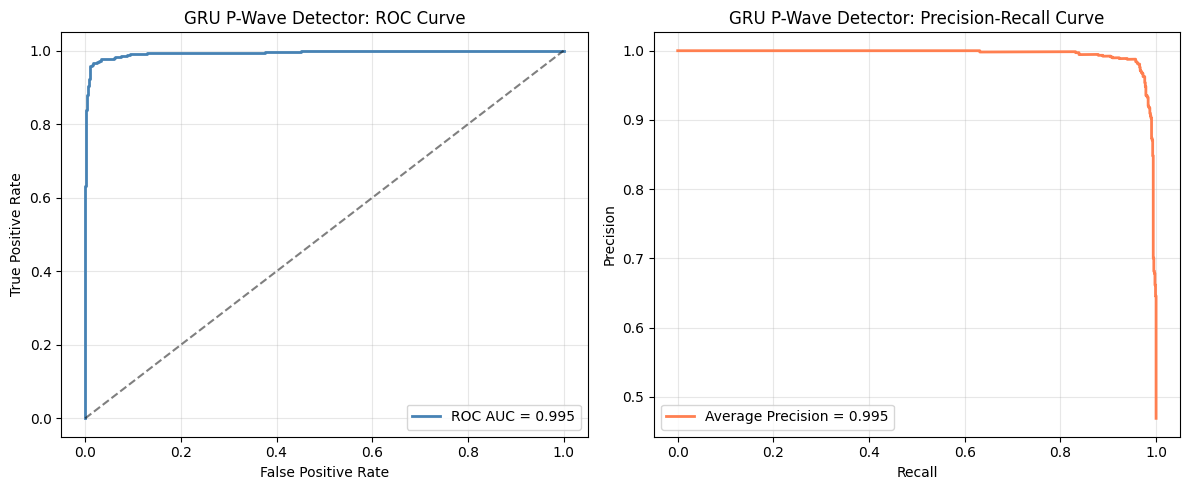

ROC AUC: 0.9945 | Average Precision: 0.9947


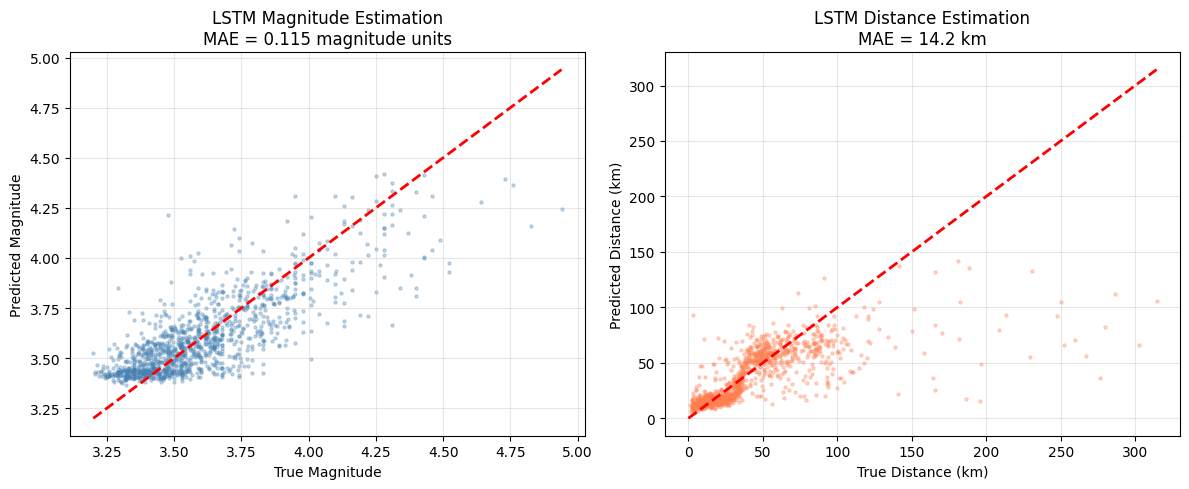

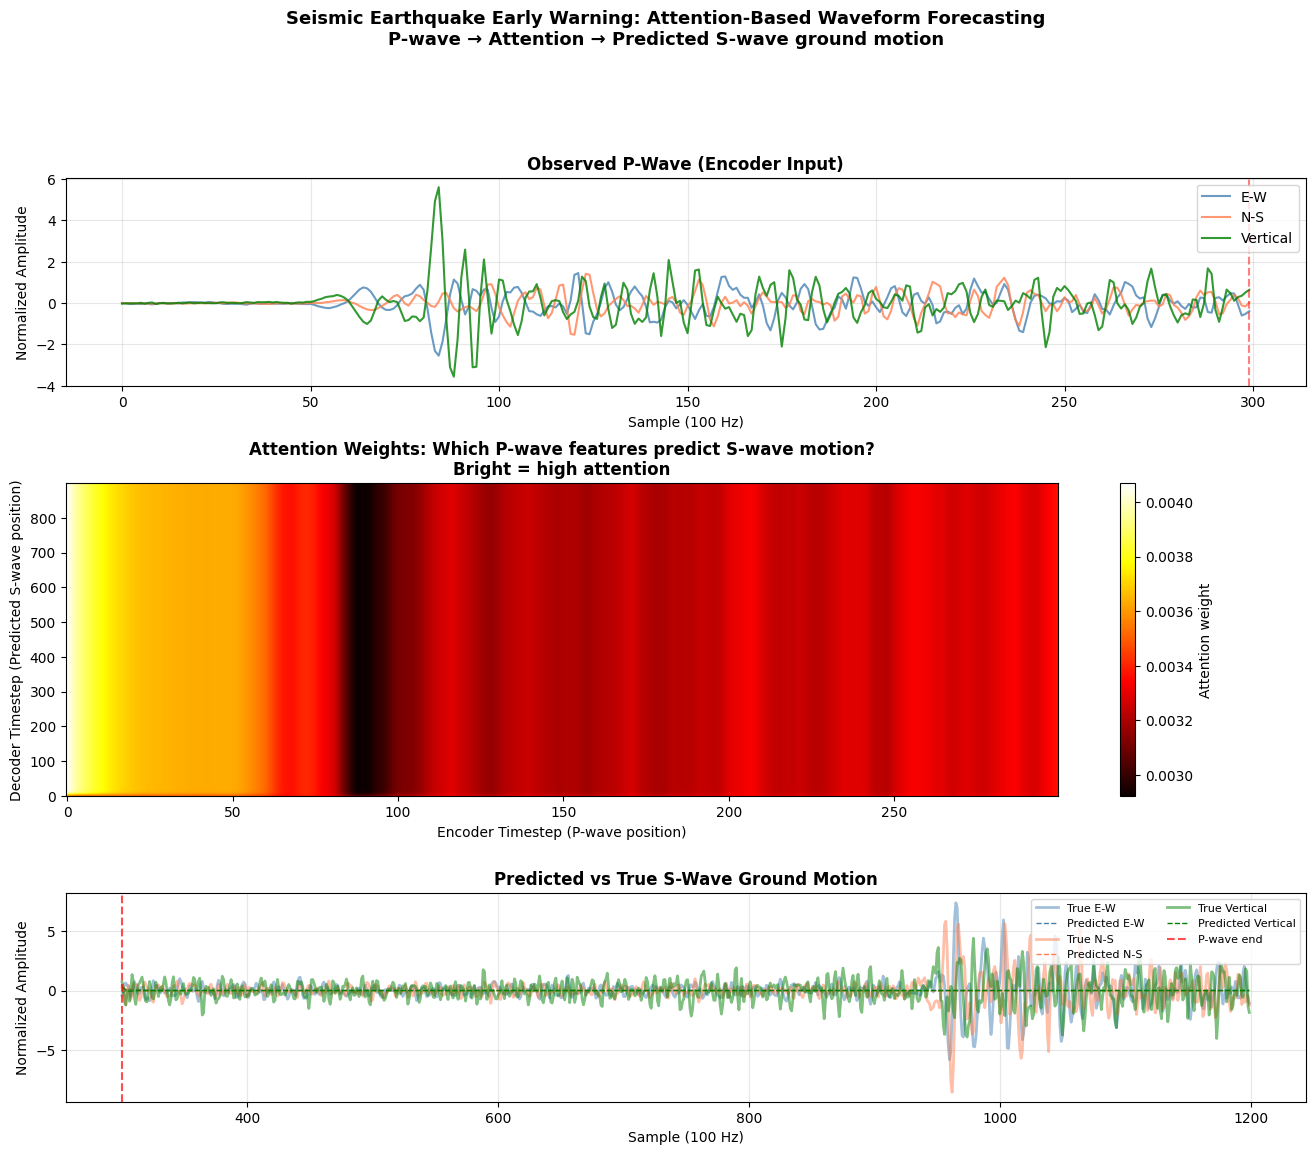


Pipeline Finished Successfully


In [9]:
# ─── Load best saved checkpoints ──────────────────────────
gru_detector.load_state_dict(
    torch.load("gru_detector_best.pth", map_location=DEVICE)
)

lstm_estimator.load_state_dict(
    torch.load("lstm_estimator_best.pth", map_location=DEVICE)
)

seq2seq.load_state_dict(
    torch.load("seq2seq_best.pth", map_location=DEVICE)
)


# ─── Visualizations ───────────────────────────────────────
plot_detection_roc(gru_detector, test_det, DEVICE)

plot_magnitude_scatter(lstm_estimator, test_est, DEVICE)

enc_sample, dec_sample = next(iter(test_s2s))

plot_attention_waveform(
    seq2seq,
    enc_sample[0],
    dec_sample[0],
    DEVICE,
)

print("\n" + "=" * 60)
print("Pipeline Finished Successfully")
print("=" * 60)